In [ ]:
#Importing libraries
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger

In [ ]:
#Loading and preprocessing data
 (x_train, _), (x_test, _) = fashion_mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
img_rows, img_cols = x_train.shape[1], x_train.shape[2]
input_dim = img_rows * img_cols
x_train_flat = x_train.reshape((len(x_train), input_dim))
x_test_flat = x_test.reshape((len(x_test), input_dim))
print("x_train shape:", x_train_flat.shape)
print("x_test shape :", x_test_flat.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 784)
x_test shape : (10000, 784)


In [ ]:
#Callbacks
#EarlyStopping (To stop training when validation loss stops improving)
#ModelCheckpoint(saves the best model)
#ReduceLROnPlateau(reduces learning rate when validation loss plateaus)
#CSVLogger(stores epoch-wise logs in a CSV file)
callbacks_list = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        "best_autoencoder.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    CSVLogger("autoencoder_training_log.csv")
]

callbacks_list

In [ ]:
#Stacked Autoencoder
input_img = Input(shape=(input_dim,))

# Encoder
encoded_1 = Dense(128, activation="relu")(input_img)
encoded_2 = Dense(64, activation="relu")(encoded_1)

# Decoder
decoded_1 = Dense(128, activation="relu")(encoded_2)
decoded_2 = Dense(input_dim, activation="sigmoid")(decoded_1)

autoencoder = Model(input_img, decoded_2)
encoder = Model(input_img, encoded_2)

autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,192 (852.31 KB)

 Trainable params: 218,192 (852.31 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Training stacked Autoencoder
history = autoencoder.fit(
    x_train_flat,
    x_train_flat,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_flat, x_test_flat),
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0058 - loss: 0.4491
Epoch 1: val_loss improved from None to 0.31296, saving model to best_autoencoder.keras

Epoch 1: finished saving model to best_autoencoder.keras
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.0097 - loss: 0.3691 - val_accuracy: 0.0158 - val_loss: 0.3130 - learning_rate: 0.0010
Epoch 2/20
231/235 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0145 - loss: 0.3070
Epoch 2: val_loss improved from 0.31296 to 0.29958, saving model to best_autoencoder.keras

Epoch 2: finished saving model to best_autoencoder.keras
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0154 - loss: 0.3034 - val_accuracy: 0.0148 - val_loss: 0.2996 - learning_rate: 0.0010
Epoch 3/20
224/235 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0165 - loss: 0.2970
Epoch 3: val_loss improved from 0.29958 to 0.29378, saving model to best_autoencoder.keras

Epoch 3: finished saving model to best_autoencoder.keras
235/235 ━━━━━━━

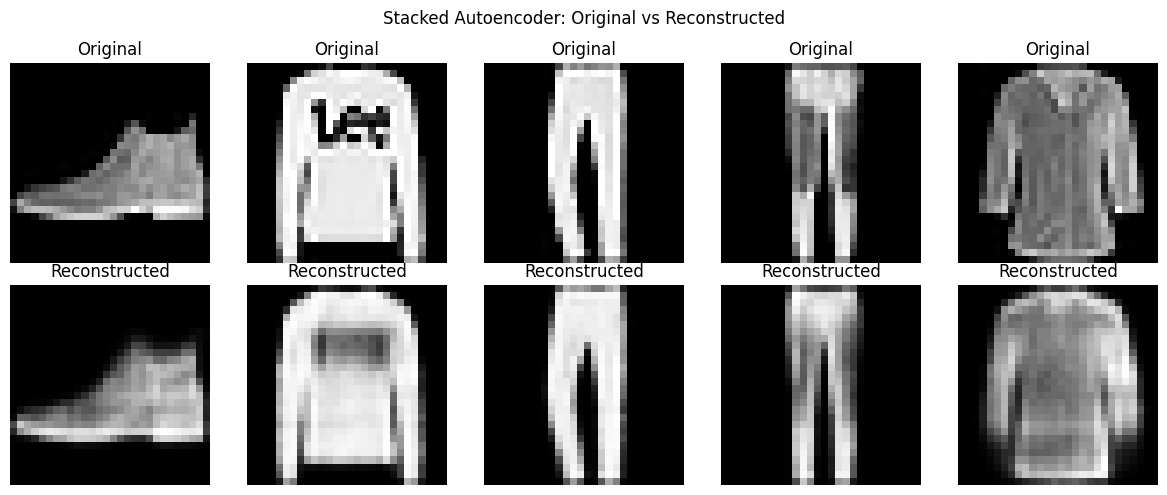

In [ ]:
#Visualizing Original and Reconstructed Images
n = 5
plt.figure(figsize=(12, 5))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_flat[i].reshape(img_rows, img_cols), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(img_rows, img_cols), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.suptitle("Stacked Autoencoder: Original vs Reconstructed")
plt.tight_layout()
plt.show()

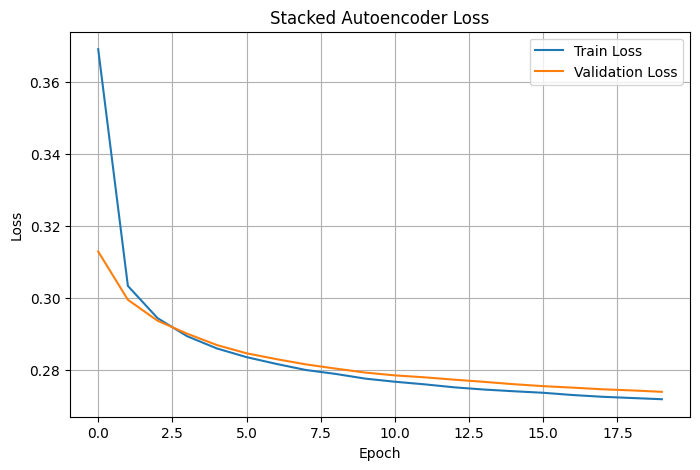

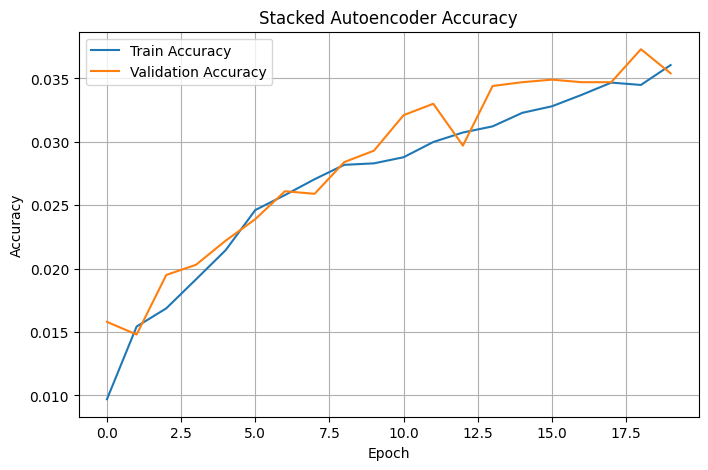

In [ ]:
#Plotloss and Accuracy for stacked Autoencoder
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Stacked Autoencoder Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Stacked Autoencoder Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Building a Denoising Autoencoder
noise_factor = 0.5

x_train_noisy = x_train_flat + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_train_flat.shape
)
x_test_noisy = x_test_flat + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_test_flat.shape
)

x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

print("Noisy train shape:", x_train_noisy.shape)
print("Noisy test shape :", x_test_noisy.shape)

Noisy train shape: (60000, 784)
Noisy test shape : (10000, 784)


In [ ]:
input_img_noise = Input(shape=(input_dim,))

# Encoder
den_encoded_1 = Dense(128, activation="relu")(input_img_noise)
den_encoded_2 = Dense(64, activation="relu")(den_encoded_1)

# Decoder
den_decoded_1 = Dense(128, activation="relu")(den_encoded_2)
den_decoded_2 = Dense(input_dim, activation="sigmoid")(den_decoded_1)

denoising_autoencoder = Model(input_img_noise, den_decoded_2)

denoising_autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

denoising_autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,192 (852.31 KB)

 Trainable params: 218,192 (852.31 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Training the Denoising Autoencoder
callbacks_denoise = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        "best_denoising_autoencoder.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    CSVLogger("denoising_autoencoder_training_log.csv")
]

history_denoise = denoising_autoencoder.fit(
    x_train_noisy,
    x_train_flat,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy, x_test_flat),
    callbacks=callbacks_denoise,
    verbose=1
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0049 - loss: 0.4687
Epoch 1: val_loss improved from None to 0.33163, saving model to best_denoising_autoencoder.keras

Epoch 1: finished saving model to best_denoising_autoencoder.keras
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.0071 - loss: 0.3902 - val_accuracy: 0.0105 - val_loss: 0.3316 - learning_rate: 0.0010
Epoch 2/20
218/235 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0122 - loss: 0.3262
Epoch 2: val_loss improved from 0.33163 to 0.32003, saving model to best_denoising_autoencoder.keras

Epoch 2: finished saving model to best_denoising_autoencoder.keras
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0130 - loss: 0.3226 - val_accuracy: 0.0144 - val_loss: 0.3200 - learning_rate: 0.0010
Epoch 3/20
220/235 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0128 - loss: 0.3151
Epoch 3: val_loss improved from 0.32003 to 0.31386, saving model to best_denoising_autoencoder.keras

Epoch 3: finished savi

## Predict Using the Denoising Autoencoder

In [ ]:
denoised_imgs = denoising_autoencoder.predict(x_test_noisy)
denoised_imgs.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


(10000, 784)

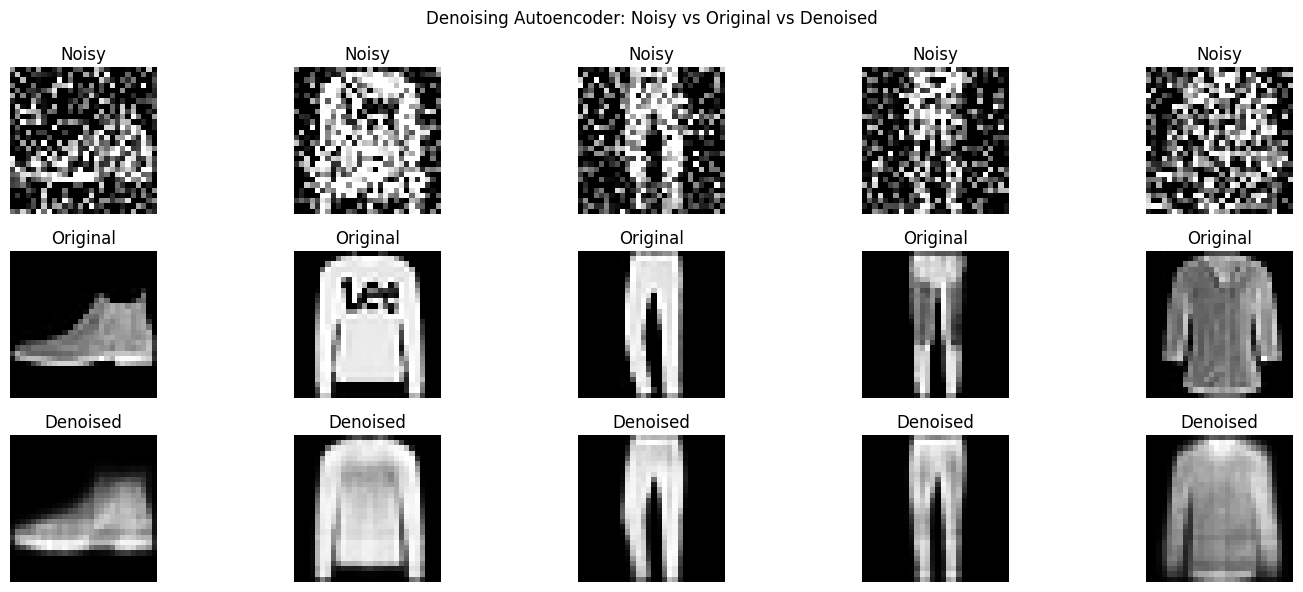

In [ ]:
#Visualizing Noisy, Original and Denoised Images
n = 5
plt.figure(figsize=(15, 6))

for i in range(n):
    # Noisy image
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(img_rows, img_cols), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Original image
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_flat[i].reshape(img_rows, img_cols), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Denoised image
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(denoised_imgs[i].reshape(img_rows, img_cols), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.suptitle("Denoising Autoencoder: Noisy vs Original vs Denoised")
plt.tight_layout()
plt.show()

## Plot Loss and Accuracy for Denoising Autoencoder

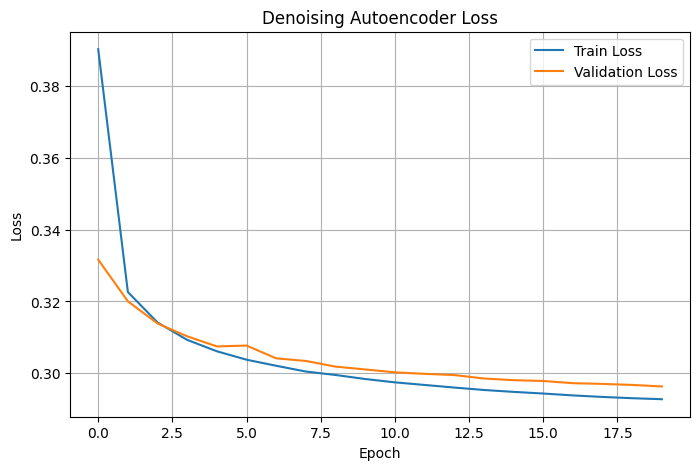

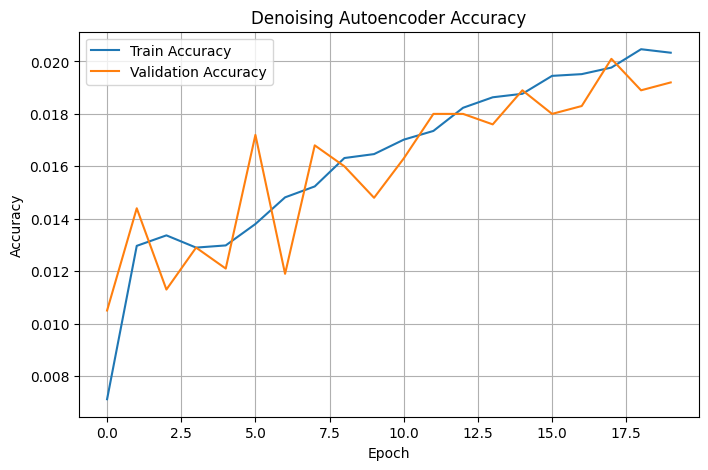

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_denoise.history["loss"], label="Train Loss")
plt.plot(history_denoise.history["val_loss"], label="Validation Loss")
plt.title("Denoising Autoencoder Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_denoise.history["accuracy"], label="Train Accuracy")
plt.plot(history_denoise.history["val_accuracy"], label="Validation Accuracy")
plt.title("Denoising Autoencoder Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()